In [78]:
import obspy
from obspy import read
import matplotlib.pyplot as plt

In [79]:
st18 = read(r"../Data/Group3/18.dat")

Sampling rate: 8000.0 Hz, Nyquist: 4000.0 Hz


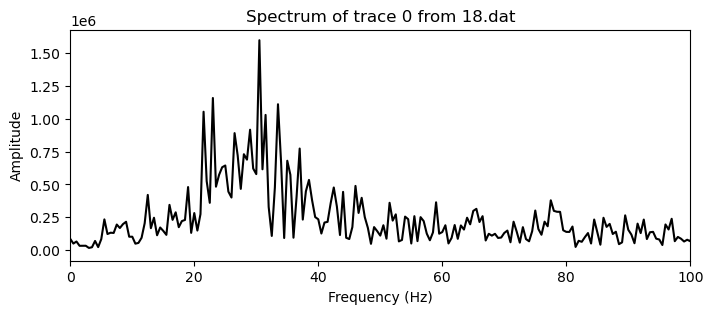

Applied bandpass 5.0-40.0 Hz


In [80]:
# inspect sampling rate and spectrum to choose a bandpass
tr0 = st18[0]
sr = tr0.stats.sampling_rate
nyquist = sr / 2
print(f"Sampling rate: {sr} Hz, Nyquist: {nyquist} Hz")

import numpy as np

n = len(tr0.data)
fft = np.abs(np.fft.rfft(tr0.data))
freq = np.fft.rfftfreq(n, d=tr0.stats.delta)

plt.figure(figsize=(8, 3))
plt.plot(freq, fft, color='black')
plt.xlim(0, min(100, nyquist))
plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude")
plt.title("Spectrum of trace 0 from 18.dat")
plt.show()

# choose a bandpass based on the spectrum
freqmin = 5.0
freqmax = 40.0
st18_filt = st18.copy()
st18_filt.filter("bandpass", freqmin=freqmin, freqmax=freqmax,
                 corners=4, zerophase=True)
print(f"Applied bandpass {freqmin}-{freqmax} Hz")

In [81]:
print(st18)

48 Trace(s) in Stream:

... | 2026-05-24T13:27:15.000000Z - 2026-05-24T13:27:16.999875Z | 8000.0 Hz, 16000 samples
...
(46 other traces)
...
... | 2026-05-24T13:27:15.000000Z - 2026-05-24T13:27:16.999875Z | 8000.0 Hz, 16000 samples

[Use "print(Stream.__str__(extended=True))" to print all Traces]


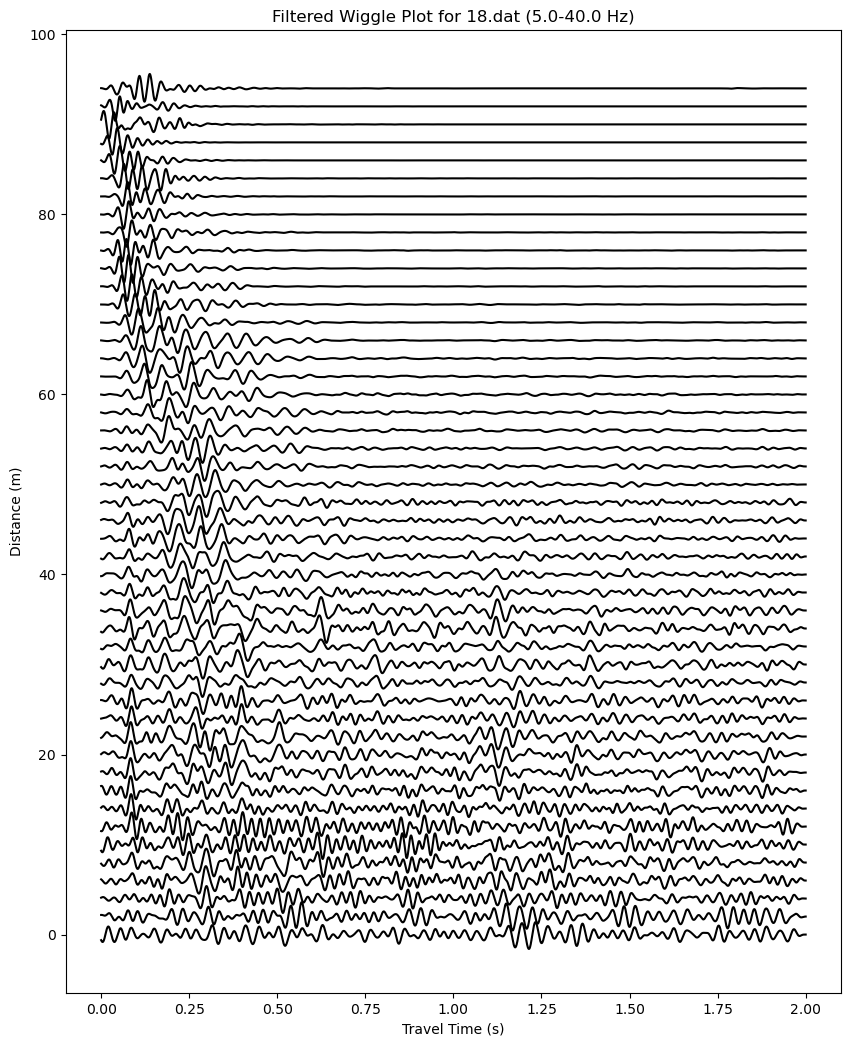

In [82]:
# plot the filtered wiggle section
scale = 1
separation = 2  # geophones are 2 m apart

plt.figure(figsize=(10, ((48+2*scale)*separation)/8))

for ch in range(48):
    tr = st18_filt[ch]
    data = tr.data
    times = tr.times()
    plt.plot(times, 0.8*separation*data/abs(data).max()+ch*separation, color='black')

plt.title(f"Filtered Wiggle Plot for 18.dat ({freqmin}-{freqmax} Hz)")
plt.xlabel("Travel Time (s)")
plt.ylabel("Distance (m)")
plt.show()

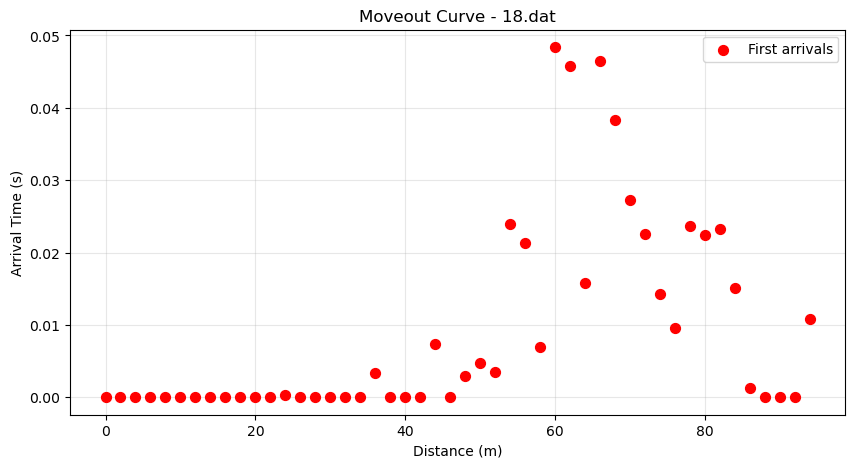

First arrival picks (time in seconds):
[0.       0.       0.       0.       0.       0.       0.       0.
 0.       0.       0.       0.       0.000375 0.       0.       0.
 0.       0.       0.003375 0.       0.       0.       0.007375 0.
 0.002875 0.00475  0.0035   0.024    0.02125  0.006875 0.048375 0.04575
 0.01575  0.0465   0.038375 0.02725  0.0225   0.01425  0.0095   0.023625
 0.022375 0.02325  0.015125 0.00125  0.       0.       0.       0.010875]

Distance range: 0 to 94 m


In [83]:
# pick first arrivals and calculate layer velocities
import numpy as np
from scipy import signal

# parameters
separation = 2  # geophones 2 m apart
num_traces = len(st18_filt)
distances = np.arange(num_traces) * separation

# pick first arrivals using energy-based threshold
first_arrivals = []
for ch in range(num_traces):
    tr = st18_filt[ch]
    data = tr.data
    times = tr.times()
    
    # envelope: amplitude of analytical signal
    analytic = signal.hilbert(data)
    envelope = np.abs(analytic)
    
    # find first arrival: where envelope exceeds threshold
    threshold = 0.05 * envelope.max()
    arrivals = np.where(envelope > threshold)[0]
    
    if len(arrivals) > 0:
        first_arrival_idx = arrivals[0]
        first_arrivals.append(times[first_arrival_idx])
    else:
        first_arrivals.append(None)

first_arrivals = np.array(first_arrivals)

# plot moveout curve
fig, ax = plt.subplots(figsize=(10, 5))
valid = ~np.isnan(first_arrivals)
ax.scatter(distances[valid], first_arrivals[valid], color='red', s=50, zorder=5, label='First arrivals')
ax.set_xlabel("Distance (m)")
ax.set_ylabel("Arrival Time (s)")
ax.set_title("Moveout Curve - 18.dat")
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()

# fit lines to identify layer boundaries
# identify "breaks" in slope by fitting segments
print("First arrival picks (time in seconds):")
print(first_arrivals)
print(f"\nDistance range: {distances[0]} to {distances[-1]} m")


Near-offset slope: 0.000002 s/m
Layer 1 velocity (v1): 402963.0 m/s

Far-offset slope: 0.000197 s/m
Layer 2 velocity (v2): 5082.5 m/s


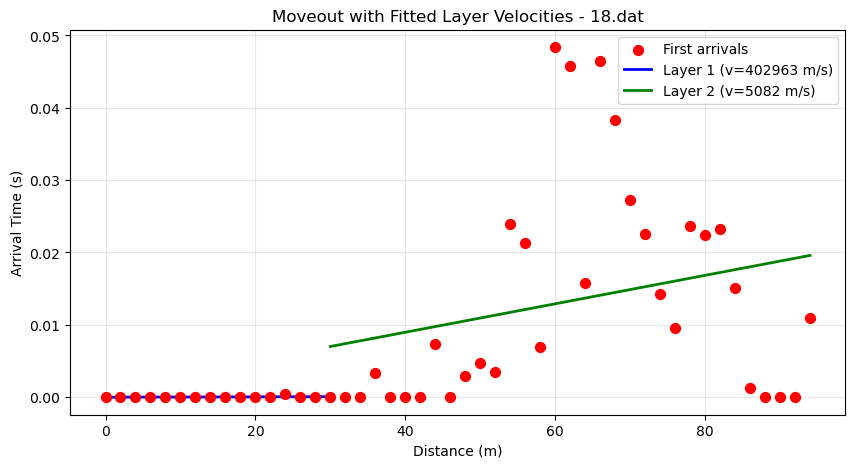


Estimated critical distance: -5.7 m
Estimated depth to Layer 2: nan m


C:\Users\raque\AppData\Local\Temp\ipykernel_46536\2444737414.py:64: RuntimeWarning: invalid value encountered in sqrt
  h1 = (v1 * v2) / (2 * np.sqrt(v2**2 - v1**2)) * t_crit


In [84]:
# fit layer velocities and estimate layer depths
from scipy.optimize import curve_fit

# remove any NaN values for fitting
mask = ~np.isnan(first_arrivals)
dist_valid = distances[mask]
time_valid = first_arrivals[mask]

# fit a two-layer refraction model: 
# t = x/v1 (first layer)
# t = x/v2 + 2*h1*sqrt(1/v1^2 - 1/v2^2) (second layer)
# where v1 < v2, h1 is depth to second layer

# simple approach: fit two lines to identify breakpoint
# visually identify break (knee) in the curve

# fit line to near offsets (first layer)
near_offset_dist = dist_valid[dist_valid <= 30]  # adjust as needed
near_offset_time = time_valid[:len(near_offset_dist)]

if len(near_offset_dist) > 2:
    p1 = np.polyfit(near_offset_dist, near_offset_time, 1)
    v1 = 1 / p1[0]  # velocity = distance / time slope
    print(f"Near-offset slope: {p1[0]:.6f} s/m")
    print(f"Layer 1 velocity (v1): {v1:.1f} m/s")

# fit line to far offsets (second layer)
far_offset_dist = dist_valid[dist_valid >= 30]
far_offset_time = time_valid[-len(far_offset_dist):]

if len(far_offset_dist) > 2:
    p2 = np.polyfit(far_offset_dist, far_offset_time, 1)
    v2 = 1 / p2[0]
    print(f"\nFar-offset slope: {p2[0]:.6f} s/m")
    print(f"Layer 2 velocity (v2): {v2:.1f} m/s")

# plot moveout with fitted lines
fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(distances[valid], first_arrivals[valid], color='red', s=50, zorder=5, label='First arrivals')

# plot fitted lines
if len(near_offset_dist) > 2:
    fit_time_1 = np.polyval(p1, near_offset_dist)
    ax.plot(near_offset_dist, fit_time_1, 'b-', linewidth=2, label=f'Layer 1 (v={v1:.0f} m/s)')

if len(far_offset_dist) > 2:
    fit_time_2 = np.polyval(p2, far_offset_dist)
    ax.plot(far_offset_dist, fit_time_2, 'g-', linewidth=2, label=f'Layer 2 (v={v2:.0f} m/s)')

ax.set_xlabel("Distance (m)")
ax.set_ylabel("Arrival Time (s)")
ax.set_title("Moveout with Fitted Layer Velocities - 18.dat")
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()

# estimate depth to second layer from intercept difference
if len(near_offset_dist) > 2 and len(far_offset_dist) > 2:
    # critical distance: where velocities intersect
    x_crit = (p2[1] - p1[1]) / (p1[0] - p2[0])
    t_crit = np.polyval(p1, x_crit)
    
    # depth to second layer
    h1 = (v1 * v2) / (2 * np.sqrt(v2**2 - v1**2)) * t_crit
    print(f"\nEstimated critical distance: {x_crit:.1f} m")
    print(f"Estimated depth to Layer 2: {h1:.1f} m")


In [85]:
# Calculate depth from critical distance using refraction formula
import numpy as np

# User-provided values from Refrapy
v1 = 1000.0  # m/s - first layer (slow)
v2 = 3800.0  # m/s - second layer (fast)
x_crit = 62.0  # m - critical distance (where slope changes)

# Calculate critical angle
critical_angle_rad = np.arcsin(v1 / v2)
critical_angle_deg = np.degrees(critical_angle_rad)

# Calculate depth using refraction formula:
# h1 = x_crit / (2 * sqrt((v2/v1)^2 - 1))
depth = x_crit / (2.0 * np.sqrt((v2/v1)**2 - 1))

print(f"Layer 1 velocity (v1): {v1} m/s")
print(f"Layer 2 velocity (v2): {v2} m/s")
print(f"Critical distance (x_c): {x_crit} m")
print(f"\nCritical angle: {critical_angle_deg:.2f}°")
print(f"Velocity ratio (v2/v1): {v2/v1:.2f}")
print(f"\n*** Depth to Layer 2: {depth:.2f} m ***")

# Verify using alternative formula with critical angle
depth_check = x_crit / (2.0 * np.tan(critical_angle_rad))
print(f"Verification (using tan): {depth_check:.2f} m")


Layer 1 velocity (v1): 1000.0 m/s
Layer 2 velocity (v2): 3800.0 m/s
Critical distance (x_c): 62.0 m

Critical angle: 15.26°
Velocity ratio (v2/v1): 3.80

*** Depth to Layer 2: 8.46 m ***
Verification (using tan): 113.65 m


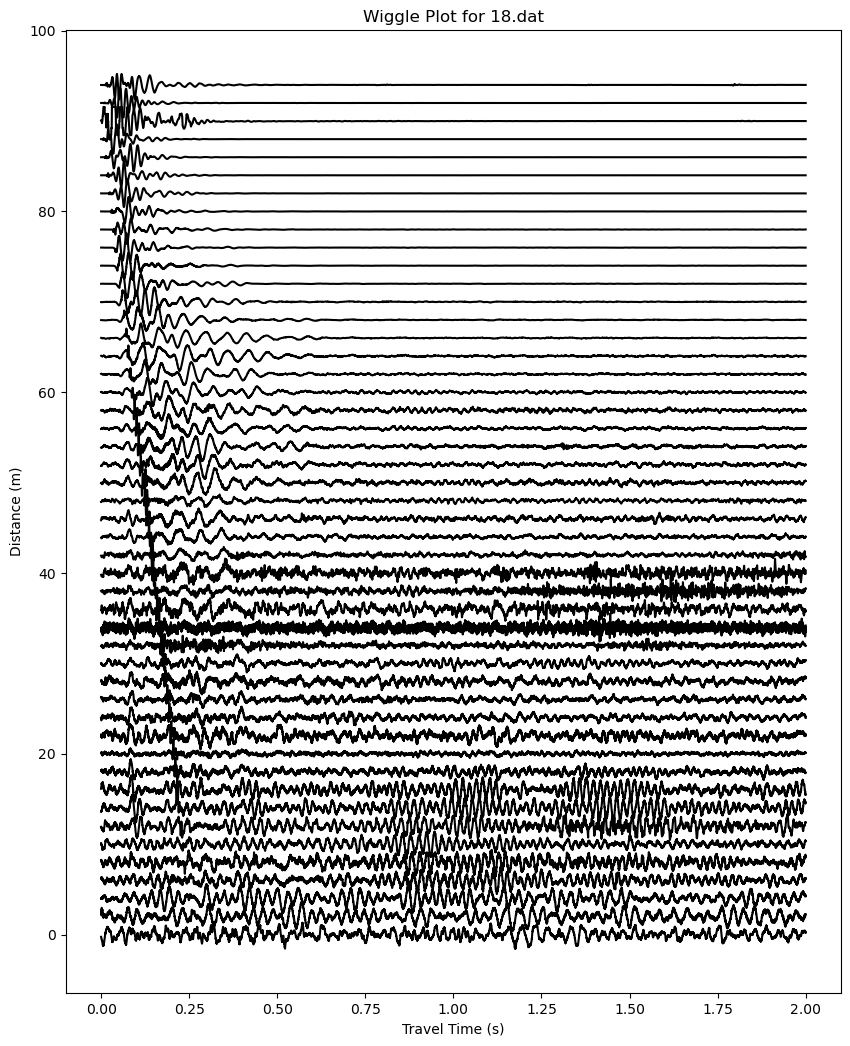

In [86]:
# create image with pyplot.
# y axis is distance in meters (geophones 2 m apart), x axis is travel time in seconds.

scale = 1
separation = 2  # geophones are 2 m apart

plt.figure(figsize=(10, ((48+2*scale)*separation)/8))

for ch in range(48):
    tr = st18[ch]
    data = tr.data
    times = tr.times()
    plt.plot(times, 0.8*separation*data/abs(data).max()+ch*separation, color='black')

plt.title("Wiggle Plot for 18.dat")
plt.xlabel("Travel Time (s)")
plt.ylabel("Distance (m)")
plt.show()


In [87]:
# load 03.dat and apply the same bandpass used above
st03 = read(r"../Data/Group3/03.dat")
st03_filt = st03.copy()
st03_filt.filter("bandpass", freqmin=freqmin, freqmax=freqmax,
                 corners=4, zerophase=True)
print(st03)

48 Trace(s) in Stream:

... | 2026-05-24T12:21:32.000000Z - 2026-05-24T12:21:33.999875Z | 8000.0 Hz, 16000 samples
...
(46 other traces)
...
... | 2026-05-24T12:21:32.000000Z - 2026-05-24T12:21:33.999875Z | 8000.0 Hz, 16000 samples

[Use "print(Stream.__str__(extended=True))" to print all Traces]


In [88]:
# parse a Refrapick .sgt file (pyGIMLi shot/geophone format)
def read_sgt(path):
    with open(path, "r") as f:
        lines = [ln.strip() for ln in f if ln.strip()]
    # header: "N # shot/geophone points"
    n_pts = int(lines[0].split()[0])
    # next n_pts lines after the "#x y" comment are sensor x,y
    i = 1
    if lines[i].startswith("#"):
        i += 1
    sensors = np.array([list(map(float, lines[i + k].split()))
                        for k in range(n_pts)])
    i += n_pts
    # "M # measurements"
    n_meas = int(lines[i].split()[0]); i += 1
    if lines[i].startswith("#"):
        i += 1
    meas = np.array([list(map(float, lines[i + k].split()))
                     for k in range(n_meas)])
    # columns: shot_idx (1-based), geophone_idx (1-based), travel time (s)
    return sensors, meas

picks_path = r"../Refrapy/group3_howelsen_hill_first_picks/picks/03_first_picks.sgt"
sensors, meas = read_sgt(picks_path)
shot_idx = np.unique(meas[:, 0].astype(int))
print(f"shots in file: {shot_idx}  (x = {sensors[shot_idx - 1, 0]} m)")
print(f"{len(meas)} picks, geophones 1..{int(meas[:, 1].max())}")

shots in file: [1]  (x = [0.] m)
48 picks, geophones 1..48


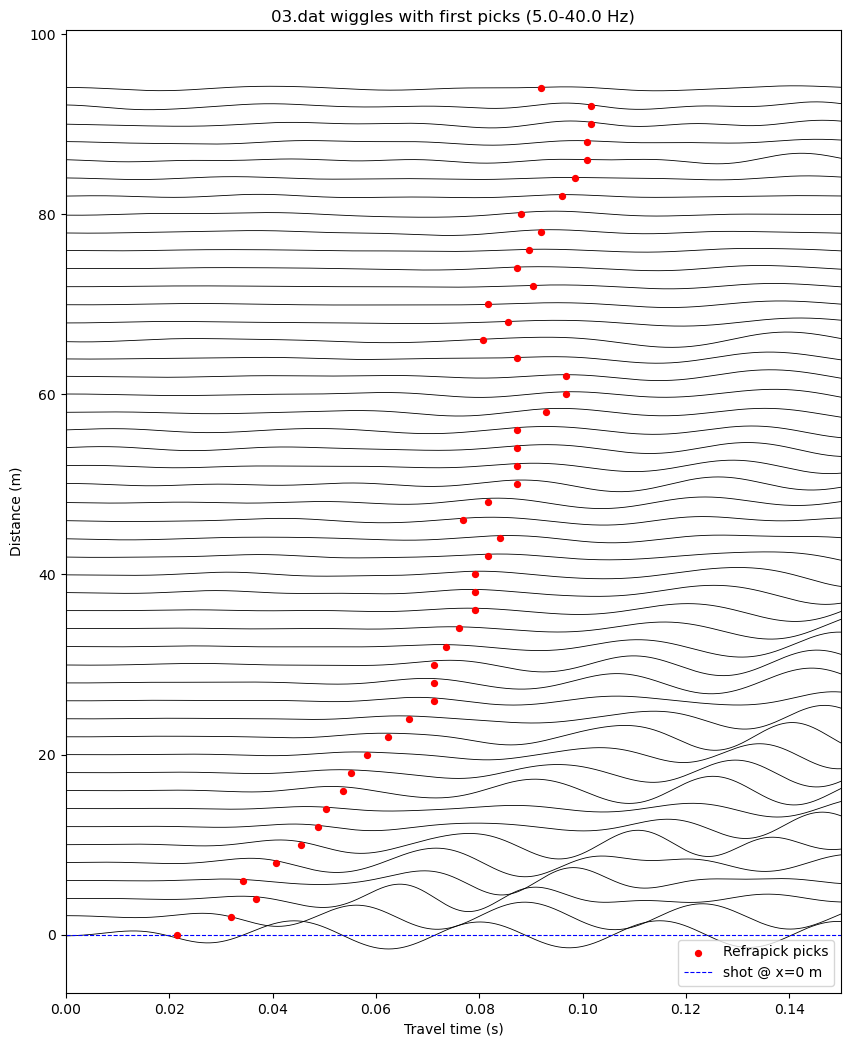

In [89]:
# wiggle plot of 03.dat with first-pick times overlaid
scale = 1
separation = 2  # geophone spacing (m)
n_traces = len(st03_filt)

plt.figure(figsize=(10, ((n_traces + 2*scale)*separation)/8))

for ch in range(n_traces):
    tr = st03_filt[ch]
    plt.plot(tr.times(),
             0.8*separation*tr.data/abs(tr.data).max() + ch*separation,
             color='black', linewidth=0.6)

# overlay picks: geophone index (1-based) -> y = (g-1)*separation
g = meas[:, 1].astype(int)
t = meas[:, 2]
y_pick = (g - 1) * separation
plt.scatter(t, y_pick, color='red', s=18, zorder=5, label='Refrapick picks')

# mark the shot location(s) on the y-axis
for s in shot_idx:
    x_shot = sensors[s - 1, 0]
    plt.axhline(x_shot, color='blue', linestyle='--', linewidth=0.8,
                label=f'shot @ x={x_shot:.0f} m')

plt.title(f"03.dat wiggles with first picks ({freqmin}-{freqmax} Hz)")
plt.xlabel("Travel time (s)")
plt.ylabel("Distance (m)")
plt.xlim(0, 0.15)  # zoom to first arrivals; widen if you want full record
plt.legend(loc='lower right')
plt.show()

  Layer 1 (direct): V =   485.1 m/s, t_intercept =  24.81 ms  (n = 6)
  Layer 2 (refractor): V =   840.6 m/s, t_intercept =  35.45 ms  (n = 15)
  Layer 3 (refractor): V =  3158.0 m/s, t_intercept =  68.60 ms  (n = 27)

Depth to layer 2 (h1): 10.53 m   (V1=485, V2=841)
Depth to layer 3 (h1+h2): 21.74 m   (V3=3158)


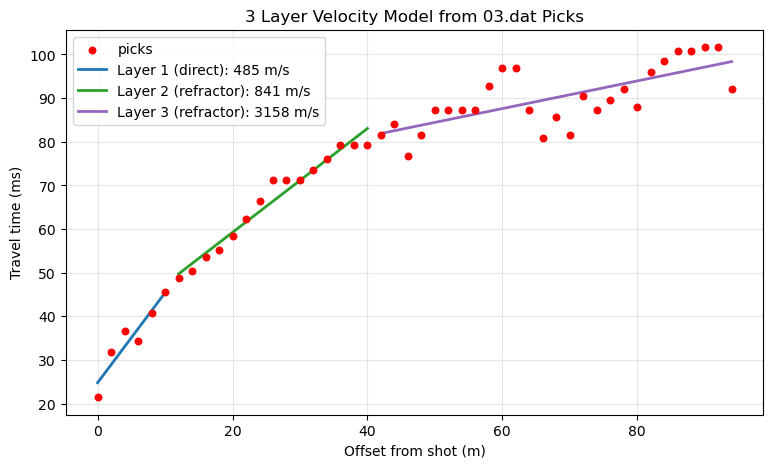

In [90]:
# --- intercept-time analysis for the picks from 03.dat (shot at x = 0) ---
# Define one segment per layer by the offset range it covers (m).
# Edit these ranges by looking at the t-x curve plotted below.
segments = [
    {"label": "Layer 1 (direct)",   "x_range": (0,  10)},
    {"label": "Layer 2 (refractor)", "x_range": (12, 40)},
    {"label": "Layer 3 (refractor)", "x_range": (42, 94)},
]

# build offset (x) and time (t) arrays for this shot
shot_x = sensors[shot_idx[0] - 1, 0]          # x position of the shot
g_idx  = meas[:, 1].astype(int)
x_off  = sensors[g_idx - 1, 0] - shot_x       # signed offset; here all >= 0
t_obs  = meas[:, 2]

# fit each segment
fits = []
for seg in segments:
    lo, hi = seg["x_range"]
    m = (x_off >= lo) & (x_off <= hi)
    if m.sum() < 2:
        print(f"  {seg['label']}: only {m.sum()} pick(s), skipping")
        continue
    slope, intercept = np.polyfit(x_off[m], t_obs[m], 1)
    v_app = 1.0 / slope                       # apparent velocity (m/s)
    fits.append({**seg, "slope": slope, "intercept": intercept,
                 "v": v_app, "mask": m})
    print(f"  {seg['label']}: V = {v_app:7.1f} m/s, "
          f"t_intercept = {intercept*1000:6.2f} ms  "
          f"(n = {m.sum()})")

# --- depths from intercept-time (flat-layer assumption) ---
# h1 from layers 1 & 2:   h1 = ti2 * V1 * V2 / (2 * sqrt(V2^2 - V1^2))
# h2 from layers 1, 2, 3: h2 = (ti3 - 2*h1*sqrt(1/V1^2 - 1/V3^2))
#                              * V2 * V3 / (2 * sqrt(V3^2 - V2^2))
if len(fits) >= 2:
    V1, V2 = fits[0]["v"], fits[1]["v"]
    ti2    = fits[1]["intercept"]
    h1 = ti2 * V1 * V2 / (2 * np.sqrt(V2**2 - V1**2))
    print(f"\nDepth to layer 2 (h1): {h1:.2f} m   (V1={V1:.0f}, V2={V2:.0f})")
if len(fits) >= 3:
    V3  = fits[2]["v"]
    ti3 = fits[2]["intercept"]
    term = ti3 - 2*h1*np.sqrt(1.0/V1**2 - 1.0/V3**2)
    h2   = term * V2 * V3 / (2 * np.sqrt(V3**2 - V2**2))
    print(f"Depth to layer 3 (h1+h2): {h1 + h2:.2f} m   (V3={V3:.0f})")

# --- t-x plot with fitted lines ---
plt.figure(figsize=(9, 5))
plt.scatter(x_off, t_obs*1000, color='red', s=22, zorder=5, label='picks')
colors = ['tab:blue', 'tab:green', 'tab:purple', 'tab:orange']
for k, fit in enumerate(fits):
    xs = np.array(fit["x_range"], dtype=float)
    ys = (fit["slope"]*xs + fit["intercept"]) * 1000
    plt.plot(xs, ys, color=colors[k % len(colors)], linewidth=2,
             label=f'{fit["label"]}: {fit["v"]:.0f} m/s')
plt.xlabel("Offset from shot (m)")
plt.ylabel("Travel time (ms)")
plt.title(f"3 Layer Velocity Model from 03.dat Picks")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## Loop: per-side velocity model for every Group 3 shot

For every shot in `all_first_picks_80-40hz.sgt`, the t–x curve on each side of the shot is fit **independently** — no mirroring. The number of layers per side (1, 2, or 3) is chosen automatically by BIC, so a side that doesn't show a clear slope break gets a 1-layer fit. Apparent velocities must increase with offset for a multi-layer fit to be accepted.

- **Left side** = geophones at offsets < shot position (red)
- **Right side** = geophones at offsets > shot position (blue)
- Solid line = layer 1, dashed = layer 2, dotted = layer 3
- Depths come from the standard flat-layer intercept-time formulas (same as cell above).


In [91]:
# ---- helpers: per-side piecewise refraction fit ----
def _line_fit(x, t):
    s, i = np.polyfit(x, t, 1)
    sse = float(np.sum((s*x + i - t)**2))
    return s, i, sse

def fit_piecewise(x, t, kmax=3, min_per_seg=3):
    """Fit a piecewise-linear t-x model with k = 1..kmax segments.

    Constraints
    -----------
    - each segment has >= min_per_seg points
    - slopes strictly decrease (so apparent velocities increase with offset)

    Selection
    ---------
    k is chosen by BIC = n*log(SSE/n) + (3k - 1)*log(n).

    Returns
    -------
    dict with keys k, breaks (segment-end indices, exclusive of last),
    slopes, intercepts, sse, bic.  None if no fit is possible.
    """
    n = len(x)
    candidates = []

    if n >= min_per_seg:
        s1, i1, sse = _line_fit(x, t)
        candidates.append({"k":1, "breaks":[], "slopes":[s1],
                           "intercepts":[i1], "sse":sse})

    if n >= 2*min_per_seg and kmax >= 2:
        best = None
        for b in range(min_per_seg, n - min_per_seg + 1):
            s1, i1, e1 = _line_fit(x[:b], t[:b])
            s2, i2, e2 = _line_fit(x[b:], t[b:])
            if s2 >= s1:
                continue
            sse = e1 + e2
            if best is None or sse < best["sse"]:
                best = {"k":2, "breaks":[b], "slopes":[s1,s2],
                        "intercepts":[i1,i2], "sse":sse}
        if best is not None:
            candidates.append(best)

    if n >= 3*min_per_seg and kmax >= 3:
        best = None
        for b1 in range(min_per_seg, n - 2*min_per_seg + 1):
            for b2 in range(b1 + min_per_seg, n - min_per_seg + 1):
                s1, i1, e1 = _line_fit(x[:b1], t[:b1])
                s2, i2, e2 = _line_fit(x[b1:b2], t[b1:b2])
                s3, i3, e3 = _line_fit(x[b2:], t[b2:])
                if not (s1 > s2 > s3):
                    continue
                sse = e1 + e2 + e3
                if best is None or sse < best["sse"]:
                    best = {"k":3, "breaks":[b1,b2], "slopes":[s1,s2,s3],
                            "intercepts":[i1,i2,i3], "sse":sse}
        if best is not None:
            candidates.append(best)

    if not candidates:
        return None

    for c in candidates:
        p = 3*c["k"] - 1
        c["bic"] = n * np.log(max(c["sse"], 1e-20) / n) + p * np.log(n)
    return min(candidates, key=lambda c: c["bic"])


def depths_from_fit(fit):
    """Cumulative depths to each refractor (m) from intercept times (flat layers)."""
    v  = [1.0/s for s in fit["slopes"]]
    ti = fit["intercepts"]
    depths = []
    if len(v) >= 2:
        V1, V2 = v[0], v[1]
        h1 = ti[1] * V1*V2 / (2.0 * np.sqrt(V2**2 - V1**2))
        depths.append(h1)
        if len(v) >= 3:
            V3 = v[2]
            term = ti[2] - 2*h1*np.sqrt(1.0/V1**2 - 1.0/V3**2)
            h2 = term * V2*V3 / (2.0 * np.sqrt(V3**2 - V2**2))
            depths.append(h1 + h2)
    return v, depths


16 shots: [1, 4, 7, 10, 13, 16, 19, 22, 25, 28, 31, 34, 37, 40, 43, 46]


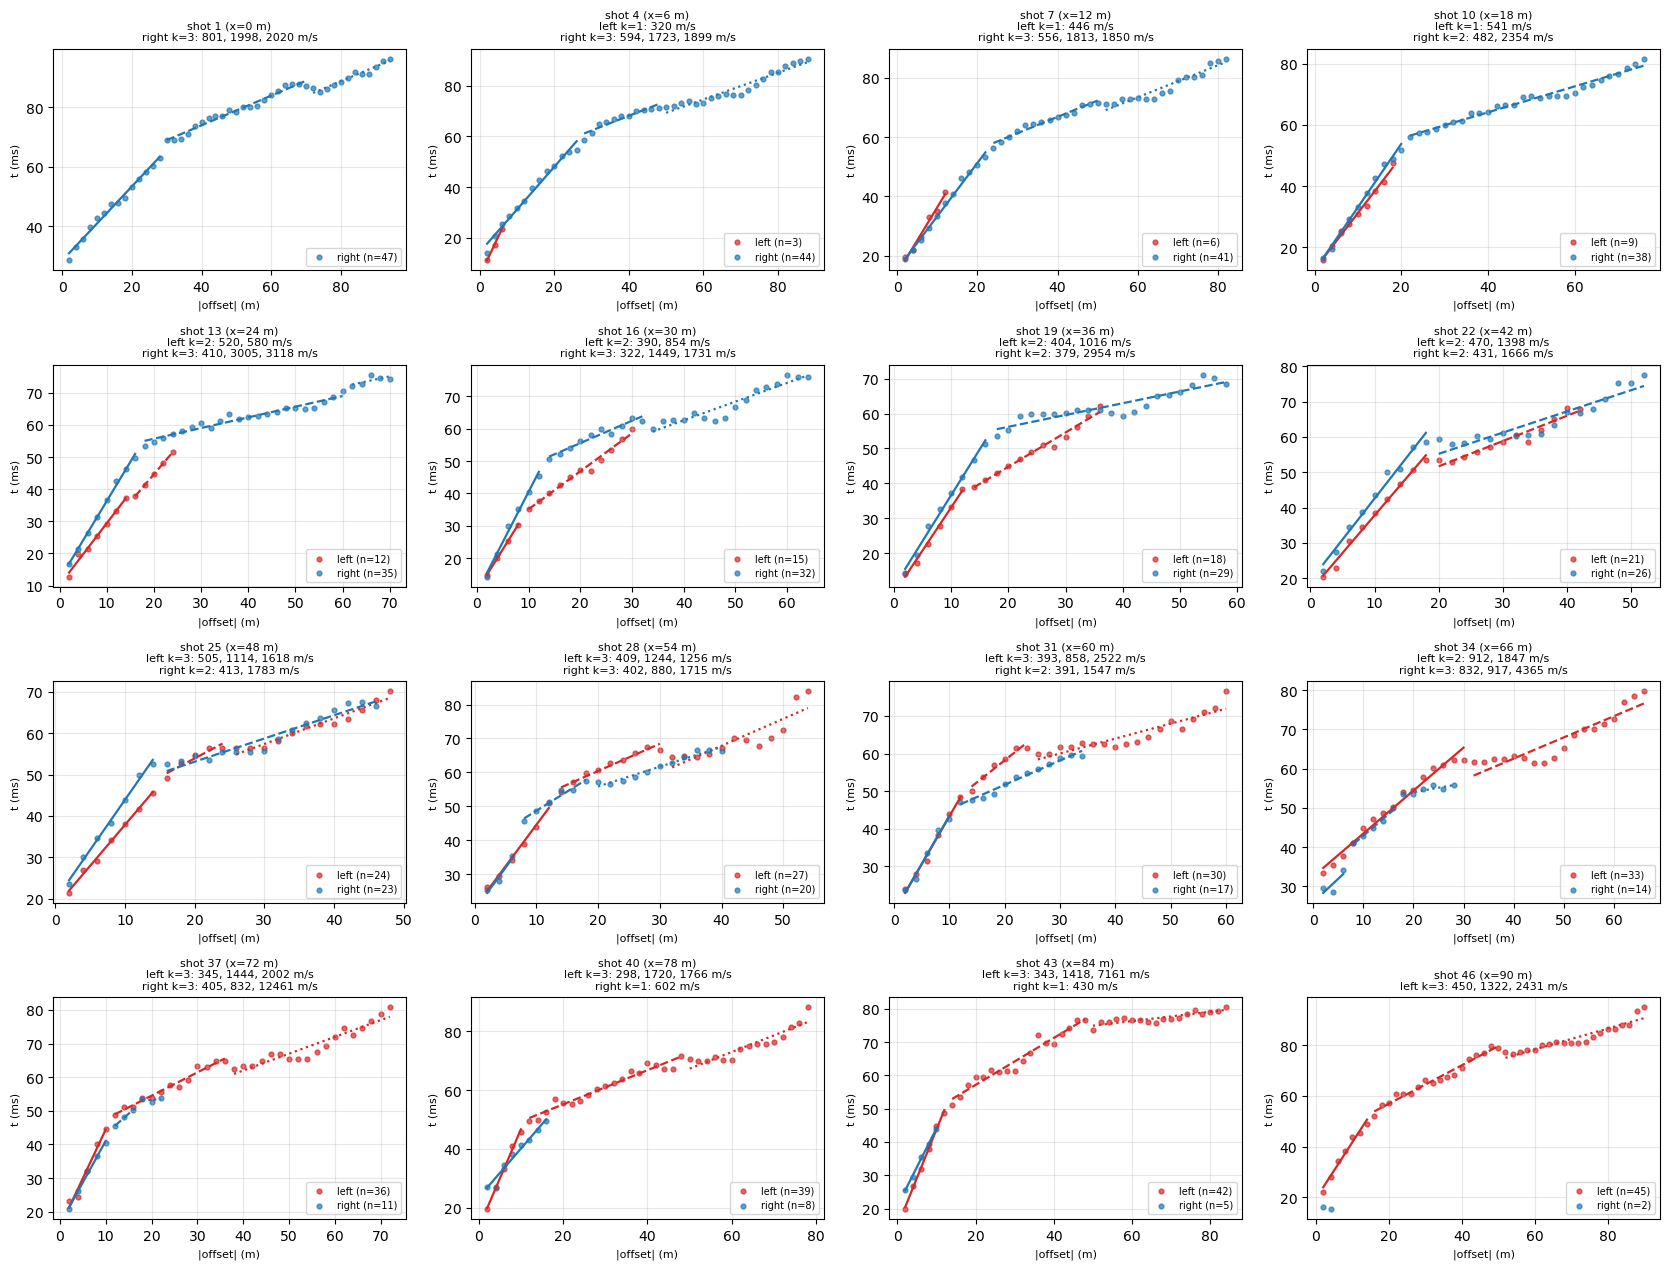

In [92]:
# load combined picks for all shots, fit each side independently, plot grid
import math

picks_path_all = r"../Refrapy/group3_howelsen_hill_first_picks/picks/all_first_picks_80-40hz.sgt"
sensors_all, meas_all = read_sgt(picks_path_all)
shot_indices = np.unique(meas_all[:, 0].astype(int))
print(f"{len(shot_indices)} shots: {shot_indices.tolist()}")

# per-shot, per-side fits
results = {}
for s in shot_indices:
    sel  = meas_all[:, 0].astype(int) == s
    g    = meas_all[sel, 1].astype(int)
    tobs = meas_all[sel, 2]
    x_shot = sensors_all[s - 1, 0]
    x_off  = sensors_all[g - 1, 0] - x_shot

    info = {"x_shot": float(x_shot)}
    for name, mask in [("left", x_off < 0), ("right", x_off > 0)]:
        if mask.sum() < 2:
            info[name] = None
            continue
        d  = np.abs(x_off[mask])
        tt = tobs[mask]
        order = np.argsort(d)
        info[name] = {"d": d[order], "t": tt[order],
                      "fit": fit_piecewise(d[order], tt[order])}
    results[int(s)] = info

# plot grid: one panel per shot, both sides overlaid (left = red, right = blue)
n_shots = len(shot_indices)
ncols   = 4
nrows   = math.ceil(n_shots / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(4.2*ncols, 3.2*nrows),
                         sharex=False, sharey=False)
axes = axes.flatten()

linestyles = ['-', '--', ':']
for idx, s in enumerate(shot_indices):
    ax    = axes[idx]
    info  = results[int(s)]
    x_shot = info["x_shot"]
    title_parts = [f"shot {s} (x={x_shot:.0f} m)"]

    for name, color in [("left", "tab:red"), ("right", "tab:blue")]:
        side = info[name]
        if side is None:
            continue
        d, tt = side["d"], side["t"]
        fit   = side["fit"]
        ax.scatter(d, tt*1000, color=color, s=12, alpha=0.7,
                   label=f"{name} (n={len(d)})")
        if fit is None:
            continue
        starts = [0] + fit["breaks"]
        ends   = fit["breaks"] + [len(d)]
        v_app  = [1.0/sl for sl in fit["slopes"]]
        for k in range(fit["k"]):
            xs = np.array([d[starts[k]], d[ends[k]-1]])
            ys = (fit["slopes"][k]*xs + fit["intercepts"][k]) * 1000
            ax.plot(xs, ys, color=color, lw=1.6, linestyle=linestyles[k])
        title_parts.append(
            f"{name} k={fit['k']}: " + ", ".join(f"{vi:.0f}" for vi in v_app) + " m/s"
        )

    ax.set_title("\n".join(title_parts), fontsize=8)
    ax.set_xlabel("|offset| (m)", fontsize=8)
    ax.set_ylabel("t (ms)", fontsize=8)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=7, loc='lower right')

for j in range(n_shots, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()


In [93]:
# tabular summary of all per-side fits
print(f"{'Shot':>4} {'x_shot':>7} {'Side':>6} {'k':>2}  {'Velocities (m/s)':<24}  Depths (m)")
print("-" * 74)
for s in shot_indices:
    info = results[int(s)]
    x_shot = info['x_shot']
    for name in ('left', 'right'):
        side = info[name]
        if side is None:
            print(f"{s:>4} {x_shot:>7.1f} {name:>6}   - (no picks on this side)")
            continue
        fit = side['fit']
        if fit is None:
            print(f"{s:>4} {x_shot:>7.1f} {name:>6}   - (could not fit)")
            continue
        v, dpths = depths_from_fit(fit)
        v_str = ", ".join(f"{vi:.0f}" for vi in v)
        d_str = ", ".join(f"{di:.1f}" for di in dpths) if dpths else "-"
        print(f"{s:>4} {x_shot:>7.1f} {name:>6} {fit['k']:>2}  {v_str:<24}  {d_str}")


Shot  x_shot   Side  k  Velocities (m/s)          Depths (m)
--------------------------------------------------------------------------
   1     0.0   left   - (no picks on this side)
   1     0.0  right  3  801, 1998, 2020           23.6, -8.9
   4     6.0   left  1  320                       -
   4     6.0  right  3  594, 1723, 1899           14.2, 9.2
   7    12.0   left  1  446                       -
   7    12.0  right  3  556, 1813, 1850           13.1, -4.5
  10    18.0   left  1  541                       -
  10    18.0  right  2  482, 2354                 11.6
  13    24.0   left  2  520, 580                  6.0
  13    24.0  right  3  410, 3005, 3118           10.1, 30.5
  16    30.0   left  2  390, 854                  5.1
  16    30.0  right  3  322, 1449, 1731           6.9, 3.5
  19    36.0   left  2  404, 1016                 5.5
  19    36.0  right  2  379, 2954                 9.5
  22    42.0   left  2  470, 1398                 9.3
  22    42.0  right  2  431, 1666